In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-07-01,954.592468,966.058736,953.250158,963.715439,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098083,968.151828,954.615226,968.151828,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451660,1138.553979,1115.689680,1115.689680,13338594


In [5]:
# The dataframe is not normal columns, it’s a MultiIndex (two-level columns).
# So, flattening the columns:

stk_data.columns = stk_data.columns.get_level_values(0)

In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-01,954.592468,966.058736,953.250158,963.715439,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098083,968.151828,954.615226,968.151828,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451660,1138.553979,1115.689680,1115.689680,13338594
2022-01-24,1081.973022,1139.691297,1071.598729,1126.154576,21868937


In [7]:
stk_data=stk_data[["Open", "High", "Low", "Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-07-01,963.715439,966.058736,953.250158,954.592468
2021-07-02,954.160145,970.495102,952.317341,968.743286
2021-07-05,972.110448,979.891169,969.858139,978.366882
2021-07-06,975.978096,977.775346,964.716550,966.809570
2021-07-07,968.151828,968.151828,954.615226,960.098083
...,...,...,...,...
2022-01-20,1137.552961,1142.057580,1117.054587,1127.269653
2022-01-21,1115.689680,1138.553979,1115.689680,1127.451660
2022-01-24,1126.154576,1139.691297,1071.598729,1081.973022


In [9]:
column="Close"

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])
print("Len:", data1.shape)

Len: (144, 1)


In [11]:
len(data1)

144

### Train - Test Split

In [12]:
training_size = round(len(data1) * 0.95)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]
print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]
print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

137
X_train length: (137, 1)
X_test length: (7, 1)
y_train length: (137, 1)
y_test length: (7, 1)


### Model Creation

#### ARMA Model

In [39]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from stockFunctions import rmsemape  

orders = [(1,0,2), (1,0,1), (2,0,1), (1,0,1)]

for i in orders:
    from statsmodels.tsa.arima.model import ARIMA

    # Build model
    model = ARIMA(data1, order=i)
    model_fit = model.fit()

    # Make prediction
    y_pred = model_fit.predict(start=0, end=len(data1)-1)

    from stockFunctions import rmsemape
    print("Order:", i)
    rmsemape(data1, y_pred)
    print("************")

Order: (1, 0, 2)
RMSE-Testset: 0.05842831033263475
MAPE-Testset: 1016402984357.7461
************
Order: (1, 0, 1)
RMSE-Testset: 0.05833824737274175
MAPE-Testset: 1025990255197.2433
************
Order: (2, 0, 1)
RMSE-Testset: 0.05773421956029872
MAPE-Testset: 959950093667.5712
************
Order: (1, 0, 1)
RMSE-Testset: 0.05833824737274175
MAPE-Testset: 1025990255197.2433
************


In [14]:
len(y_pred)

144

In [19]:
from statsmodels.tsa.arima.model import ARIMA
from stockFunctions import rmsemape

# Best model
i = (2,0,1)

# Build model
model = ARIMA(data1, order=i)
model_fit = model.fit()

# Make prediction
y_pred = model_fit.predict(start=0, end=len(data1)-1)

# Print results
print("Order:", i)
rmsemape(data1, y_pred)
print("************")

Order: (2, 0, 1)
RMSE-Testset: 0.05773421956029872
MAPE-Testset: 959950093667.5712
************


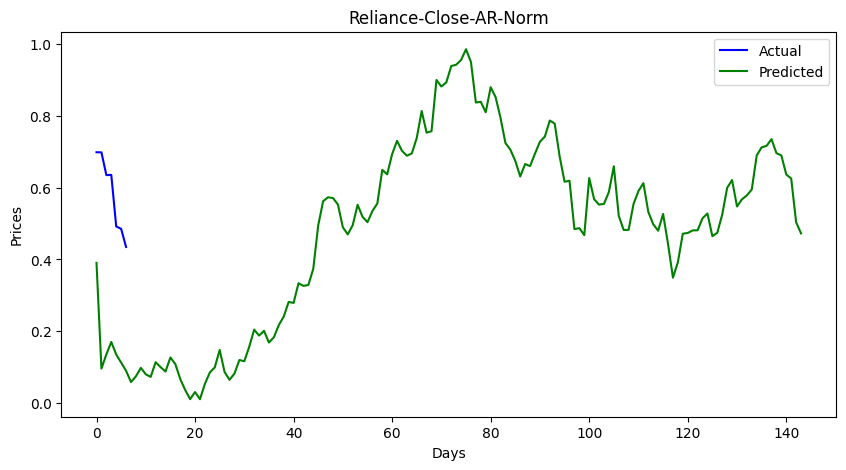

In [17]:
from stockFunctions import graph
graph(y_test, y_pred, "Actual", "Predicted", "Reliance-Close-AR-Norm", "Days", "Prices")

In [20]:
len(data1)

144

In [21]:
y_test

array([[0.69844217],
       [0.69815523],
       [0.63477151],
       [0.63534578],
       [0.49185225],
       [0.48517675],
       [0.43471343]])

### Coverting to original data

In [22]:
from stockFunctions import conversionSingle
aTestNormTable = conversionSingle(y_test, [column])

In [23]:
aTestNormTable

,Close
0,0.698442
1,0.698155
2,0.634772
3,0.635346
4,0.491852
5,0.485177
6,0.434713


In [24]:
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)

In [25]:
actual_stock_price_test_ori

array([[1147.44934082],
       [1147.35839844],
       [1127.26965332],
       [1127.45166016],
       [1081.97302246],
       [1079.8572998 ],
       [1063.86352539]])

In [26]:
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [27]:
actual_stock_price_test_oriA

,Close
0,1147.449341
1,1147.358398
2,1127.269653
3,1127.45166
4,1081.973022
5,1079.8573
6,1063.863525


In [28]:
from stockFunctions import conversionSingle

aTestNormTable = conversionSingle(y_test, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [29]:
from stockFunctions import conversionSingle

pTestNormTable = conversionSingle(y_pred, [column])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

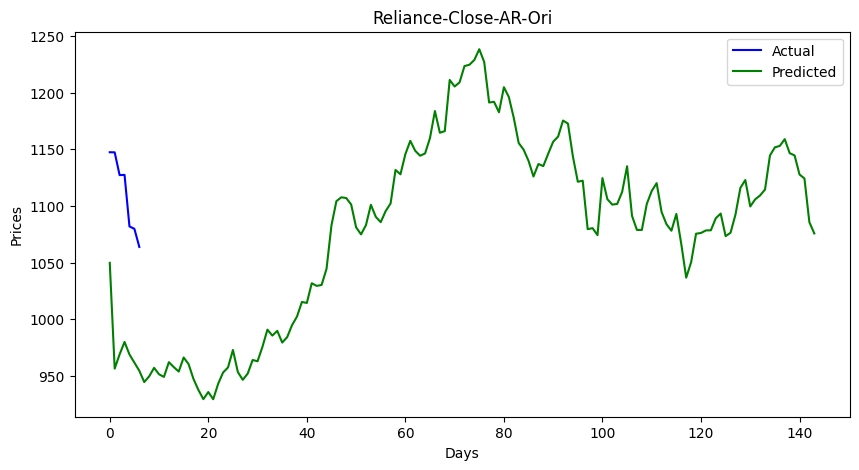

In [30]:
from stockFunctions import graph

graph(actual_stock_price_test_oriA,
      predicted_stock_price_test_oriP,
      "Actual",
      "Predicted",
      "Reliance-Close-AR-Ori",
      "Days",
      "Prices")

### Checking the model forcast

In [32]:
forecast = model_fit.predict(len(data1), len(data1)+3)

In [33]:
forecast

array([0.44640459, 0.43406236, 0.44351389, 0.43326324])

In [34]:
from stockFunctions import conversionSingle

fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

In [35]:
forecast_stock_price_test_oriF

,Closefore
0,1067.568905
1,1063.657176
2,1066.652732
3,1063.403902


In [36]:
forecast_stock_price_test_oriF.to_csv("CloseARMA.csv", index=False)

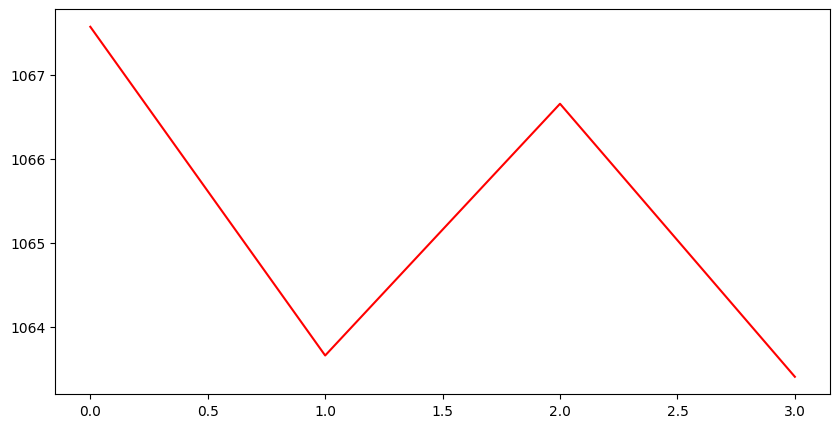

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:144], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label="Predicted")